# Fast convolution

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

In [2]:
import fitz
from IPython.display import YouTubeVideo

In [3]:
from utils import plot_pdf

In [4]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.
Is an excellent book but full of examples but, of course, do not explain everything in details.
For that parts I will quote another books and videos from YouTube.

The book puts first all theory and only after that we have a detailed example. To better understanding in this tutorial we have quotes from theory and examples together fallowing the sequence of commands

This example will not work for different vector sizes.

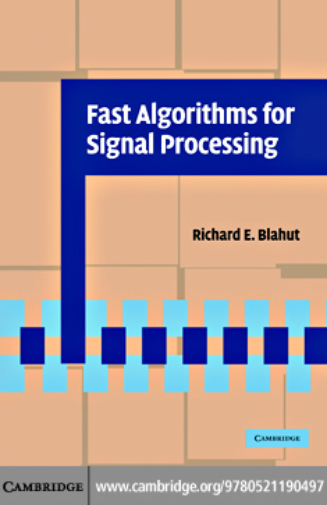

In [5]:
plot_pdf(doc[0], dpi=100)

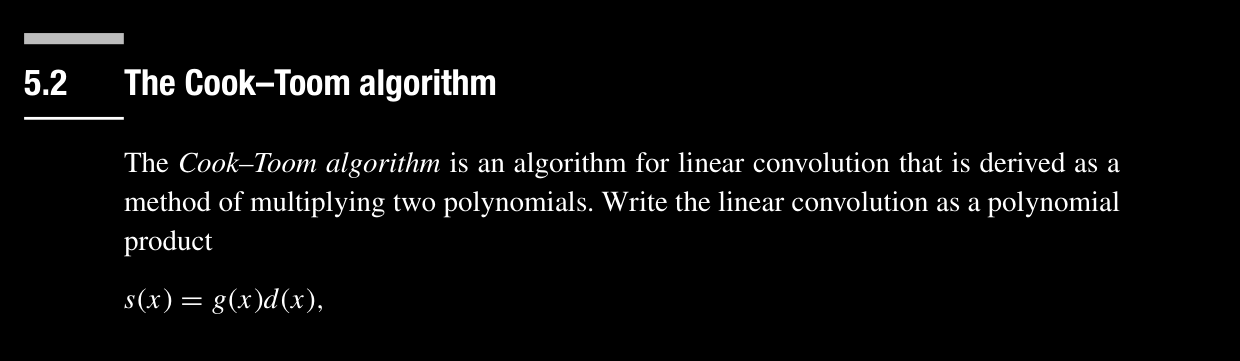

In [43]:
plot_pdf(doc[163], [.76, .95])

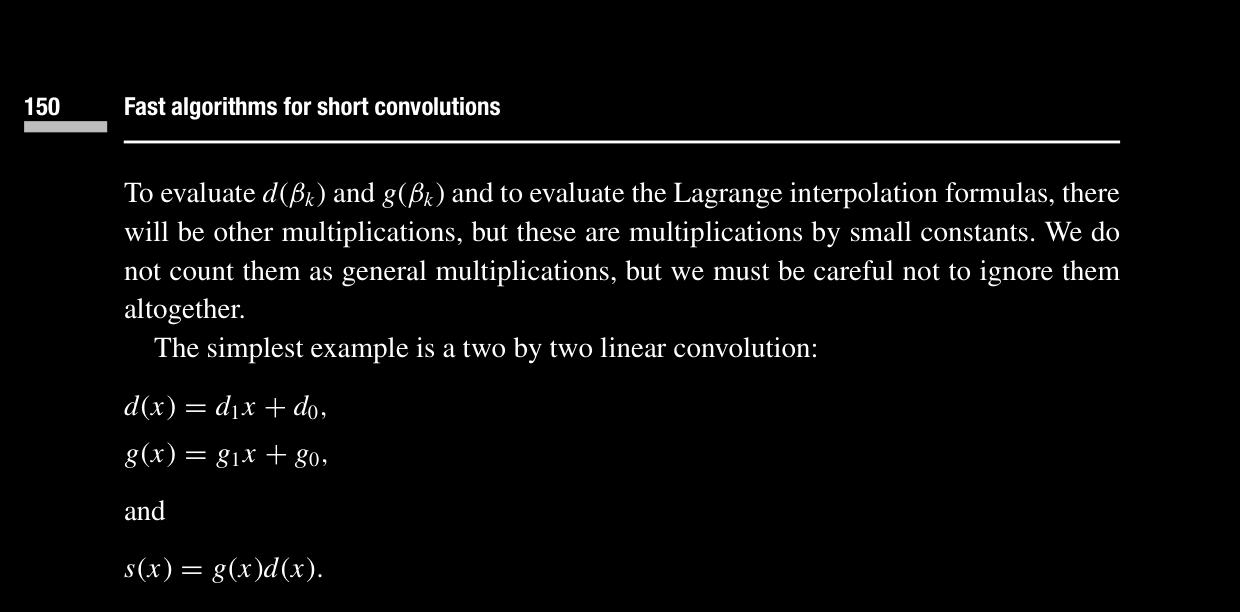

In [54]:
plot_pdf(doc[165], [0, .322])

## Start

Size of vectors

In [8]:
d_num = 2
g_num = 2

Example of vectors for the convolution

In [10]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

In [11]:
b_degree = d_num + g_num - 1
b_degree

3

In [12]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

1 1


In [13]:
x = sy.symbols("x")
x

x

In [14]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1]])

In [15]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1]])

In [16]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x

In [17]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x

In [18]:
sx = gx*dx
sx

(d_0 + d_1*x)*(g_0 + g_1*x)

In [19]:
xi = [x**i for i in range(1, sy.degree(sx.expand(), x) + 1)]
xi

[x, x**2]

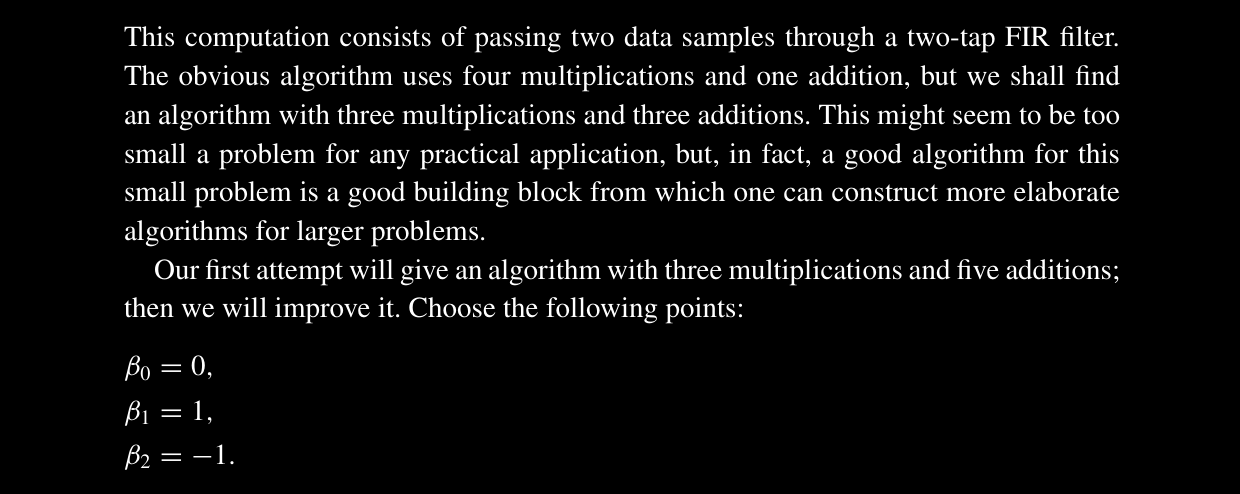

In [74]:
plot_pdf(doc[165], [.31, .57])

In [9]:
bi = [0, 1, -1]
sy.Matrix(bi)

Matrix([
[ 0],
[ 1],
[-1]])

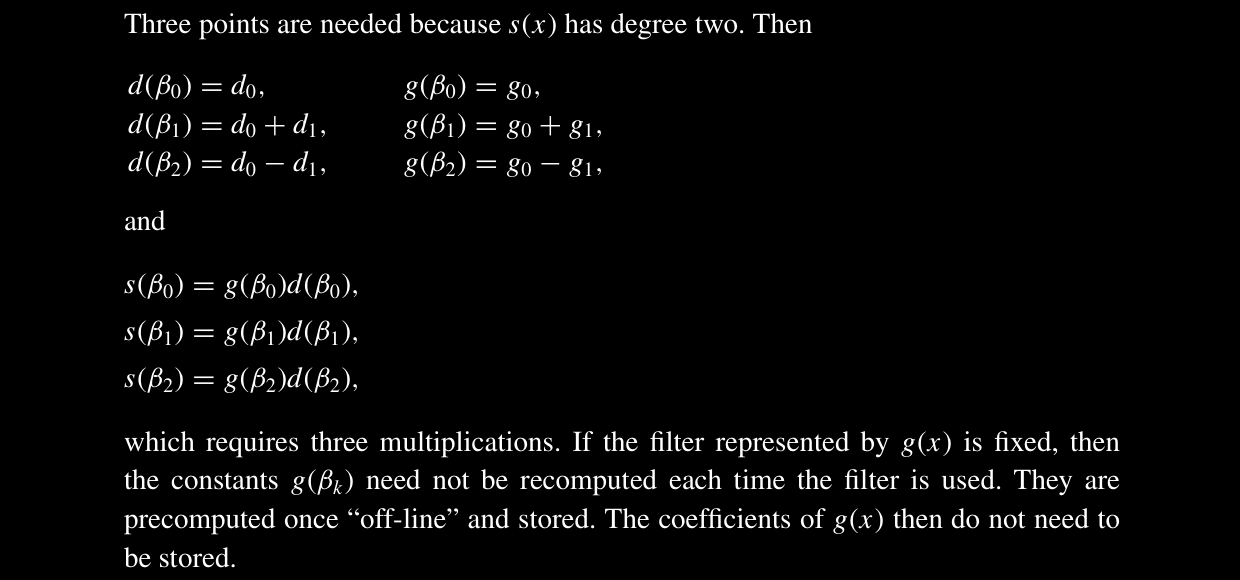

In [77]:
plot_pdf(doc[165], [.57, .875])

In [22]:
dbi = [di[0] + di[1] * b for b in bi]
sy.Matrix(dbi)

Matrix([
[      d_0],
[d_0 + d_1],
[d_0 - d_1]])

In [23]:
gbi = [gi[0] + gi[1] * b for b in bi]
sy.Matrix(gbi)

Matrix([
[      g_0],
[g_0 + g_1],
[g_0 - g_1]])

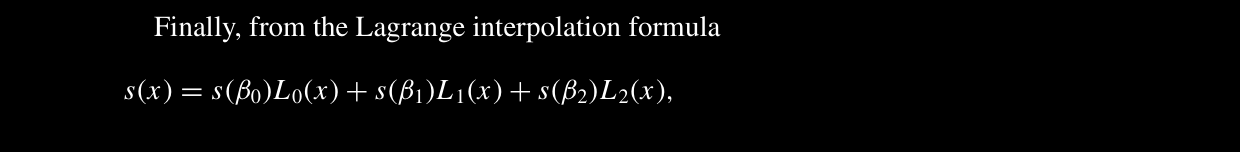

In [75]:
plot_pdf(doc[165], [.87, .95])

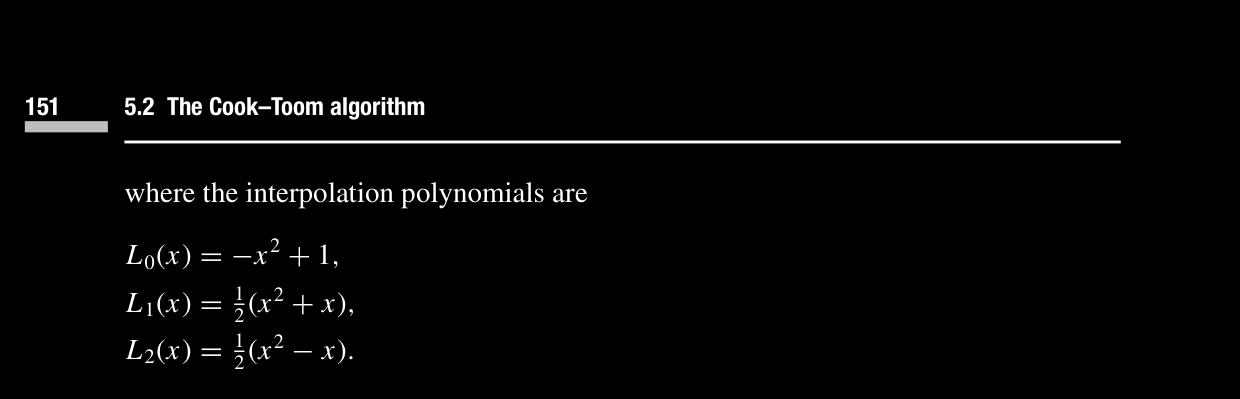

In [67]:
plot_pdf(doc[166], [0, .21])

In [24]:
cd = [sy.expand((x - b[0])*(x - b[1])) for b0, b in zip(bi, itertools.combinations(reversed(bi), len(bi)-1))]
sy.Matrix(cd)

Matrix([
[x**2 - 1],
[x**2 + x],
[x**2 - x]])

In [25]:
cq = [1/sy.expand((b0 - b[0])*(b0 - b[1])) for b0, b in zip(bi, itertools.combinations(reversed(bi), len(bi)-1))]
sy.Matrix([cq])

Matrix([[-1, 1/2, 1/2]])

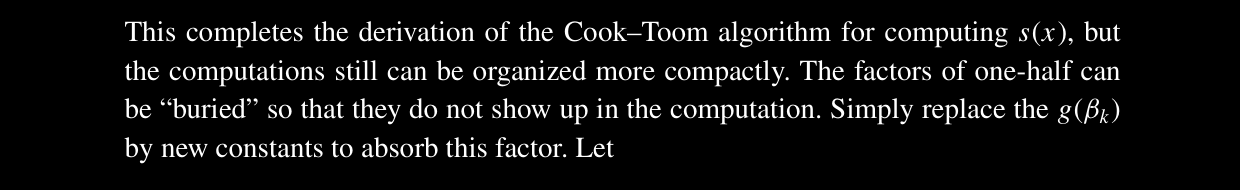

In [69]:
plot_pdf(doc[166], [.2, .3])

In [26]:
c0 = sy.Matrix([s.subs({x:0}) for s in cd])
c0.T

Matrix([[-1, 0, 0]])

In [27]:
c1 = sy.Matrix([[d.coeff(c, 1) for c in xi] for d in cd])
c1.T

Matrix([
[0, 1, -1],
[1, 1,  1]])

In [28]:
c_mtx = sy.Matrix(c0.T.tolist() + c1.T.tolist())
c_mtx

Matrix([
[-1, 0,  0],
[ 0, 1, -1],
[ 1, 1,  1]])

In [29]:
a_mtx = sy.Matrix([[b.coeff(d, 1) for d in di] for b in dbi])
a_mtx

Matrix([
[1,  0],
[1,  1],
[1, -1]])

In [30]:
b_mtx = sy.Matrix([[b.coeff(g, 1) for g in gi] for b in gbi])
b_mtx

Matrix([
[1,  0],
[1,  1],
[1, -1]])

In [31]:
bg_mtx = sy.diag(*(sy.diag(*cq) * b_mtx * gi).tolist())
bg_mtx

Matrix([
[-g_0,             0,             0],
[   0, g_0/2 + g_1/2,             0],
[   0,             0, g_0/2 - g_1/2]])

In [32]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

Matrix([
[-1, 0,  0],
[ 0, 1, -1],
[ 1, 1,  1]])*Matrix([
[-g_0,             0,             0],
[   0, g_0/2 + g_1/2,             0],
[   0,             0, g_0/2 - g_1/2]])*Matrix([
[1,  0],
[1,  1],
[1, -1]])*Matrix([
[d_0],
[d_1]])

## Example

In [33]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

{d_0: 1, d_1: 2, g_0: 1, g_1: 2}

In [34]:
si = s.subs(subs)
si

Matrix([
[-1, 0,  0],
[ 0, 1, -1],
[ 1, 1,  1]])*Matrix([
[-1,   0,    0],
[ 0, 3/2,    0],
[ 0,   0, -1/2]])*Matrix([
[1,  0],
[1,  1],
[1, -1]])*Matrix([
[1],
[2]])

In [35]:
sy.expand(sx)

d_0*g_0 + d_0*g_1*x + d_1*g_0*x + d_1*g_1*x**2

Let's compare the output polynomial matrix from direct and winograd method

In [36]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[          d_0*g_0],
[d_0*g_1 + d_1*g_0],
[          d_1*g_1]])

In [37]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Matrix([
[          d_0*g_0],
[d_0*g_1 + d_1*g_0],
[          d_1*g_1]])

Comparing numerical outputs from direct and winograd method

In [38]:
sy.Matrix(np.convolve(d_values, g_values))

Matrix([
[1],
[4],
[4]])

In [39]:
se.subs(subs)

Matrix([
[1],
[4],
[4]])